In [35]:
import numpy as np
from matplotlib import pyplot as plt
from time import time
import PT_model
from PT_model import Acoustic_2D_Cartesian_Grid
import PT_data_classes
from copy import copy
import PT_data 
import PT_routines
from scipy.ndimage import gaussian_filter

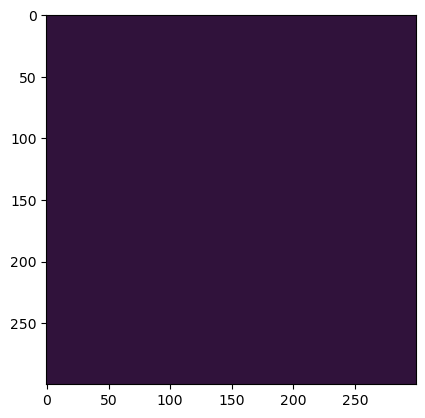

In [36]:
model_init = PT_model.load_model("Model_Init")

vmin = 1500.0
vmax = 2000.0

plt.imshow(model_init.model_params.c, cmap="turbo")

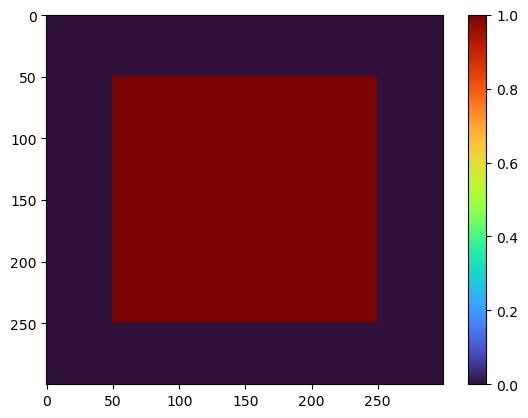

In [37]:
# create a preconditioner 

sigmoid = lambda x, x0, alpha: 1 / (1 + np.exp(-alpha*(x-x0)))

P = np.ones((model_init.model_params.Nz, model_init.model_params.Nx))
P[0:50, :] = 0.0
P[250:, :] = 0.0
P[:, 0:50] = 0.0
P[:, 250:] = 0.0


plt.imshow(P, cmap="turbo", aspect='auto')
plt.colorbar()


In [ ]:
# create particles

partilces: list[Acoustic_2D_Cartesian_Grid] = []

# number of particles in ensemble
Ne: int = 200

for i in range(Ne):
    
    # generate perturbed velocity field
    pert = np.random.randn(model_init.model_params.Nz, model_init.model_params.Nx)
    pert = P*gaussian_filter(pert, sigma=15)
    pert /=  np.max(np.abs(pert))/200.0
    c_pert = model_init.model_params.c + pert
    c_pert = np.clip(c_pert, vmin, vmax)

    # create model params for the new model object
    model_params: PT_data_classes.Acoustic_2D_Grid_model_params = copy(model_init.model_params)
    model_params.c = c_pert

    # append a new model to the particles list
    partilces.append(Acoustic_2D_Cartesian_Grid(model_params=model_params))



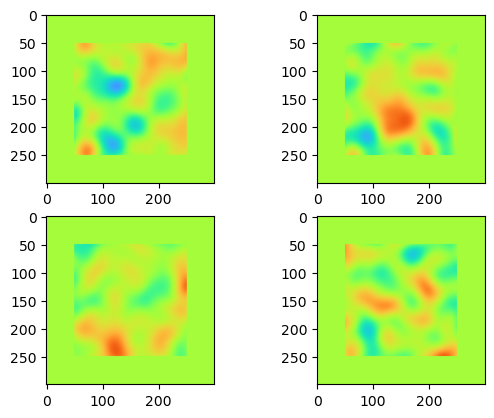

In [39]:
# visualize the first four particles

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(partilces[i].model_params.c, cmap="turbo", vmin=vmin, vmax=vmax)

0.9877925578858392


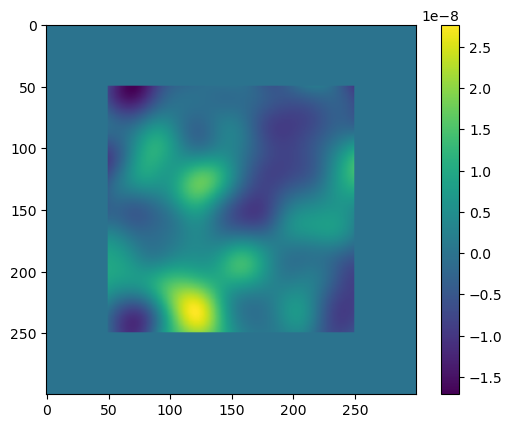

In [40]:
def kernel(m1: np.ndarray, m2:np.ndarray, eps: float) -> float: 
    return np.exp(-np.sum((m1-m2)**2) / (2 * (eps**2)))

def grad_kernel(m1: np.ndarray, m2: np.ndarray, eps: float) -> np.ndarray: 
    return -kernel(m1, m2, eps) * (m1-m2) / (eps**2)

eps = 10**5
print(kernel(partilces[0].model_params.c, partilces[1].model_params.c, eps))

plt.imshow(grad_kernel(partilces[0].model_params.c, partilces[2].model_params.c, eps))
plt.colorbar()



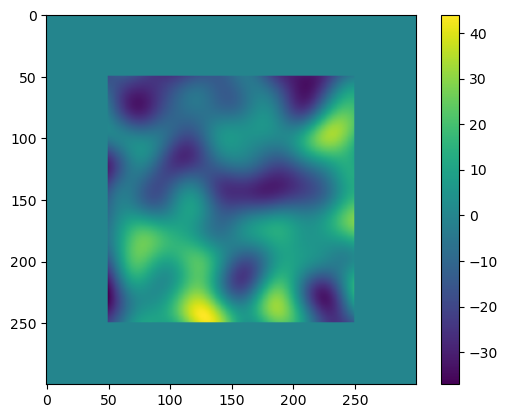

In [41]:
# set maximum update
max_update = 50.0

# compute mean value of squared gradient kernels

Mean_Max_Kenel_Amp = 0.0

for i in range(Ne):
    for j in range(Ne):

        Mean_Max_Kenel_Amp += np.abs(grad_kernel(partilces[i].model_params.c, partilces[j].model_params.c, eps)).max()

Mean_Max_Kenel_Amp /= Ne**2

alpha =  max_update / Mean_Max_Kenel_Amp

plt.imshow(alpha*grad_kernel(partilces[4].model_params.c, partilces[2].model_params.c, eps))
plt.colorbar()

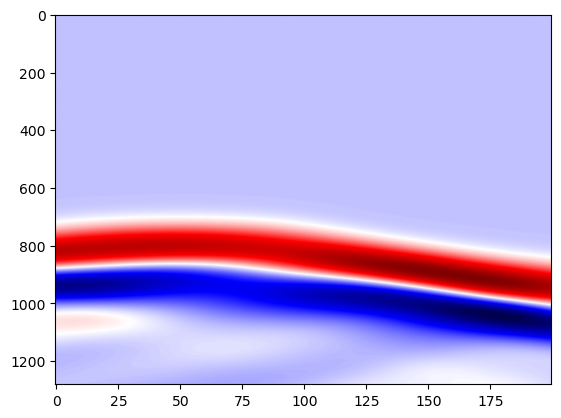

In [42]:
# load box data

obs_data_set = PT_data.load_data_set("Box_Data")

SG_plt = obs_data_set.shot_gathers[1].gather
plt.imshow(SG_plt, aspect="auto", cmap="seismic")

# create save indice
save_inds = np.arange(0, obs_data_set.shot_gathers[0].aquisition_params.Nt+1).tolist()
save_inds = save_inds[::10]

In [43]:
# set preprocessing and adjiont parameters

preprocess_params = PT_data_classes.Preprocess_params(mute=False, 
                                                         filter=None,
                                                         filter_bounds=[15.0],
                                                         normalize=False)

adjoint_params = PT_data_classes.Adjoint_params(adjoint_source="L2", additonal_parmas=[])


In [44]:
Ns = len(obs_data_set.shot_gathers)

model_list = []
aquisition_params_list = []
preprocess_params_list = []
adjoint_params_list = []
save_inds_list = []
SG_OBS_list = []

for i in range(Ne):
    for j in range(Ns):

        model_list.append(partilces[i])
        aquisition_params_list.append(obs_data_set.shot_gathers[j].aquisition_params)
        preprocess_params_list.append(preprocess_params)
        adjoint_params_list.append(adjoint_params)
        save_inds_list.append(save_inds)
        SG_OBS_list.append(obs_data_set.shot_gathers[j])


       

In [ ]:
# set the number of iterations
N_iters = 500

# initialize misfit history
misfits = []

for iter in range(N_iters):
    
    # compute sensitivity kernels
    OUT = PT_routines.Compute_Kernel_Parallel(model_list=model_list,
                                                aquisition_params_list=aquisition_params_list,
                                                preprocess_params_lsit=preprocess_params_list,
                                                adjoint_params_list=adjoint_params_list,
                                                save_inds_list=save_inds_list,
                                                SG_OBS_list=SG_OBS_list)


    #initialize gradients
    Gradients = []
    resid = 0.0

    # Sum deterministic gradients
    ind = 0
    for i in range(Ne): 
        grad = np.zeros((model_init.model_params.Nz, model_init.model_params.Nx), dtype=np.float32, order='C')
        for j in range(Ns): 
            grad += OUT[ind][0]
            resid += np.sum(OUT[ind][3])
            ind += 1
        grad *= P
        grad /= np.max(np.abs(grad))/max_update
        Gradients.append(grad)


    # Get upate direction and update each particle
    for i in range(Ne):    
        phi =  np.zeros((model_init.model_params.Nz, model_init.model_params.Nx), dtype=np.float32, order='C')

        for j in range(Ne):
            phi += (-kernel(partilces[j].model_params.c, partilces[i].model_params.c, eps)*Gradients[j] + 
                    alpha*grad_kernel(partilces[j].model_params.c, partilces[i].model_params.c, eps))
        
        phi /= Ne
        partilces[i].model_params.c += phi
        partilces[i].model_params.c = np.clip(partilces[i].model_params.c, vmin, vmax)

    # update misfit history
    misfits.append(resid)
    print("Misfit: ", misfits[-1]/misfits[0])





Misfit:  1.0
Misfit:  0.8533318053682345
Misfit:  0.736952679284871
Misfit:  0.6598763561233583
Misfit:  0.6223524089334522


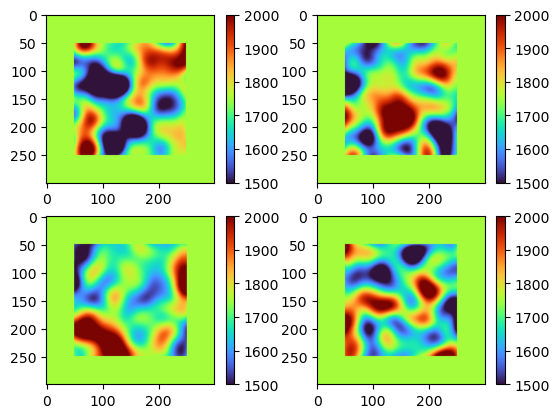

In [46]:

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(partilces[i].model_params.c, cmap="turbo", vmin=vmin, vmax=vmax)
    plt.colorbar()

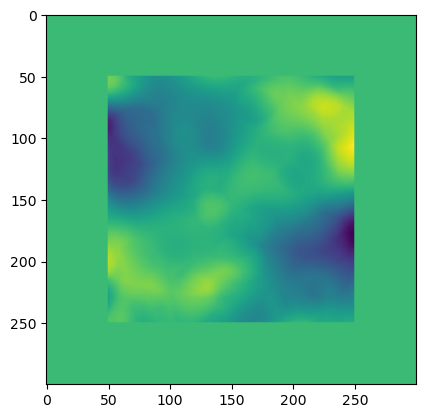

In [47]:
Mean_Model =  np.zeros((model_init.model_params.Nz, model_init.model_params.Nx))

for i in range(Ne): 
    Mean_Model += partilces[i].model_params.c
Mean_Model /= Ne

plt.imshow(Mean_Model)

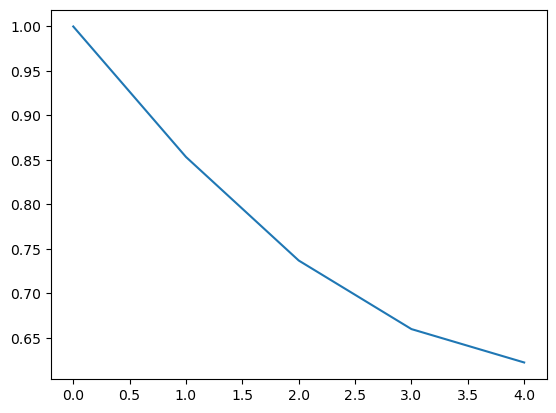

In [48]:
plt.plot(misfits/misfits[0])